# riverWQ Modelling — Predicting E. coli Contamination in NZ Rivers

This notebook builds and evaluates regression and classification models to predict E. coli contamination from catchment-level features. All preprocessing and modelling decisions are based on '01_eda.pynb'.

# 1. Setup & Data Preparation

## 1.1 Library imports

**The libraries that will be used are imported in the cell below.**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
# Data split tool
from sklearn.model_selection import train_test_split
# LogisticRegression method tool
from sklearn.linear_model import LinearRegression, LogisticRegression
# KNN model method tool
from sklearn.neighbors import KNeighborsClassifier
# Random Forest method tool
from sklearn.ensemble import RandomForestClassifier
# Classification report tool
from sklearn.metrics import classification_report
# Confusion metrix tool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, classification_report
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import StratifiedKFold

## 1.2 Dataset Loading

In [2]:
# Load the dataset and show
df = pd.read_csv('../data/riverWQ_dataset.csv')
df.shape

(396, 38)

# 2. Data Preprocessing

This section will prepare the dataset for modelling. Firstly, the rows with missing target values will be removed. And the input features will be organised into numerical and categorical groups so they can be transformaed appropriately. And the data will be split into training and test sets. A preprocessing pipeline will be built then.

## 2.1 Clean the dataset

In this section, the missing rows of the targets will be dropped. And the duplicate column 'pct_cropland' observed in the EDA will be dropped.

In [3]:
# Drop rows with missing E. coli targets and reset the index
df = df.dropna(subset=['ecoli_median', 'ecoli_band']).reset_index(drop=True)
df.shape

(339, 38)

In [4]:
# Drop duplicate land cover column
df = df.drop(columns=['pct_cropland'])
df.shape

(339, 37)

## 2.2 Define feature sets

In this section, features will be organised into different groups(numerical and categorical). Broad-level pct columns are excluded because they are exact sums of their medium-level sub-categories. Including both levels would introduce multicollinearity.

**Numerical features**: 11 medium-level land cover percentages and 'mean_annual_rainfall_mm'.

**Categorical features**: 'wfs_altitude' and 'rec_land_cover_type'.

In [5]:
numerical_features = [
    'pct_cropping_horticulture',
    'pct_indigenous_forest',
    'pct_exotic_forest',
    'pct_exotic_grassland',
    'pct_tussock_grassland',
    'pct_other_herbaceous_vegetation',
    'pct_indigenous_scrub_shrubland',
    'pct_exotic_scrub_shrubland',
    'pct_urban_area',
    'pct_natural_bare_lightly-vegetated_surfaces',
    'pct_artificial_bare_surfaces',
    'mean_annual_rainfall_mm',
]

categorical_features = [
    'wfs_altitude',
    'rec_land_cover_type',
]

feature_columns = numerical_features + categorical_features


## 2.3 Train/test split

In this section, data will be split into training and test sets before any preprocessing is fitted.

An 80/20 split will be used. And the same split is used for both regression and classfication tasks so the two models are evaluated on the same sites.

**The data will be split in the following cell.*

In [6]:
# Use .copy to avoid warning on Pandas
X = df[feature_columns].copy()
y_reg = df['ecoli_median'].copy()
y_clf = df['ecoli_band'].copy()
# Split the data and use stratify to avoid random imbalance
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    stratify=y_clf,
    random_state=42,
)

## 2.4 Build preprocessing pipeline

In this section, a 'ColumnTransformer' will be built to each feature group. Numerical features will be standardised and categorical features are one-hot encoded. The transformer will be wrapped in a 'Pipeline' together with each model later.

**The preprocessor will be built in the following cell.**

In [7]:
# Use ColumnTransformer to deal with standardscaler and onehot simultaneously.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

The preprocessor is ready to go.

# 3. Evaluation Metrics

In this section, evaluation metrics will be selected and justified for each task before building the models.


## Regression metrics

Three metrics for regression and classification will be reported as follows:

**RMSE** 
It penalises large errors more heavily. EDA shows that 'ecoli_mean' is heavily right-skewed with a long tail. Since it is a freshwater management dataset and task, misclassifying a band E site as clean would prevent it from being flagged as intervention. RMSE makes such errors invisible and help with more effective decisions.

**MAE**
It gives the typical absolute error. And MAE treats all the error equally, having MAE alongside RMSE shows whether RMSE is being driven by a small number of misses or noises.

**R²**
It is the proportion of variance in 'ecoli_median' explained by the catchment fatures. EDA found that even the strongest feature only reach Spearman around 0.5, which suggests that these data is useful but not quite signal. R² calculates how much the combined feature set captures that means how much of E. coli variation catchment characteristics alone can explain.

## Classification metrics

**Macro-F1**
It averages F1 across the five bands with equal weight. EDA showed that bands B and C have fewer samples that a classifier would tend to sacrifice for accuracy. But Macro-F1 treats them equally.

**Precision, recall and F1 based on per-class**
EDA showed that feature separation is obvious for band E but weak between A-D. And per-class metrics show the statistics directly.

**Confusion matrix**
The dataset is about water contamination. Thus, misclassifying A with B might not affect greatly but confusing A with E will be a serious one. Confusion matrix is the only way to see which kinds of mistakes the model is making and in EDA, it is reported that errors will likely be concentrated in the middle bands.

**Accuracy**
It is used for reference since it is the most familiar metrics while it will not be used for model selections.

- A 'DummyClassifier' is also reported as a baseline. Because the majority bands are so large, the dummy will work as a reference and comparison.

# 4. Regression Modelling

This section builds and tunes three regression models to predict 'ecoli_median' alongside a 'DummyRegressor' baseline. Each model is built as a pipeline combining the preprocessor with the model and wrapped in 'TransformedTargetRegressor' to apply log1p to the target during training. 

Hyperparameters are tuned via 5-fold cross-validation on the training set, and the three models are compared on their CV scores to select the final regression model. 

## 4.1 Dummy baseline

Establish a 'DummyRegressor' baseline with 'mean', which always predicts the training mean of 'ecoli_median'.

The dummy is evaluated using 5-fold cross-validation on the training set, with the same metric(RMSE) used to compare the other models.

In [8]:
# Build the dummy 
dummy_reg = DummyRegressor(strategy='mean')

# 5-fold CV
cv_scores = cross_val_score(
    dummy_reg,
    X_train,
    y_reg_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error'
)

# Convert to positive numbers while getting the mean
dummy_cv_rmse = -cv_scores.mean()
dummy_cv_rmse_std = cv_scores.std()

print(f"Dummy CV RMSE: {dummy_cv_rmse:.1f} ± {dummy_cv_rmse_std:.1f} MPN/100mL")



Dummy CV RMSE: 381.7 ± 104.3 MPN/100mL


The output of the dummy baseline is above. And the trained models in 4.2-4.4 should outperform this baseline, or the catchment-level features carry no useful signal for the regression task then.

## 4.2 Linear Regression

Linear Regression has no regularisation hyperparameters to tune in its plain form. The model is wrapped in TransformedTargetRegressor so the log transformation of 'ecoli_median' identified in EDA(skewness≈3.05) is applied during training, and with predictions returned on the original scale.

CV RMSE on the training set is reported with the same 5-fold scheme used for the dummy, so the two are directly comparable. And which is also for checking under or over fitting.

In [9]:
# Build the pipeline with preprocessor and LR
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())  
])
# Wrap the pipeline with log transformation
lr_reg = TransformedTargetRegressor(
    regressor=lr_pipe,
    func=np.log1p, # Transform before training
    inverse_func=np.expm1 # Return after training
)
# 5-fold CV
cv_scores = cross_val_score(
    lr_reg,
    X_train,
    y_reg_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring= 'neg_root_mean_squared_error'
)
# Calculate and reverse on CV
lr_cv_rmse = -cv_scores.mean()
lr_cv_rmse_std = cv_scores.std()
# Calculate trained RMSE
lr_reg.fit(X_train, y_reg_train)
lr_train_pred = lr_reg.predict(X_train)
lr_train_rmse = root_mean_squared_error(y_reg_train, lr_train_pred)

print(f"Linear Regression CV RMSE:    {lr_cv_rmse:.1f} ± {lr_cv_rmse_std:.1f} MPN/100mL")
print(f"Linear Regression Train RMSE: {lr_train_rmse:.1f} MPN/100mL")

Linear Regression CV RMSE:    436.2 ± 172.8 MPN/100mL
Linear Regression Train RMSE: 322.3 MPN/100mL


The CV RMSE(436±172.8) is higher than the Train RMSE(322), which means the model performs better on the training set. The large STD also shows that performance varies a lot depending on which sites are held out. It suggests that the result is driven by a few extreme high 'ecoli_median' sites. The comprehensive comparison will be conducted after all the models are trained.

## 4.3 Random Forest Regressor

Random Forest is an ensemble of decision trees that can capture non-linear patterns. The same log transformation will be applied although the random faorest model is not very sensitive to input data, while learning the traning set, massive 'y' will confuse the learning.

Three key hyperparameters are tuned with 5-fold cross-validation:

- 'n_estimators': number of trees in the forest
- 'max_depth': maximum depth of each tree (controls model capacity)
- 'min_samples_leaf': minimum samples required at a leaf (controls overfitting)

In [10]:
# Build pipeline: preprocessing + random forest
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
# Wrap with log transformation
rf_reg = TransformedTargetRegressor(
    regressor=rf_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)
# Hyperparameter grid
param_grid = {
    'regressor__model__n_estimators': [100, 300, 500], # The first hyperparameter to be tuned
    'regressor__model__max_depth': [5, 10, 20, None],
    'regressor__model__min_samples_leaf': [1, 2, 5],
}
# GridSearchCV with 5-fold CV
rf_grid = GridSearchCV(
    rf_reg,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    return_train_score=True # Return the training score for visualisation
)
# Train the 5-fold CV mmodel
rf_grid.fit(X_train, y_reg_train)
# Grab the best result
rf_cv_rmse = -rf_grid.best_score_
rf_best_params = rf_grid.best_params_
# Train the model with the best combo
rf_train_pred = rf_grid.best_estimator_.predict(X_train)
rf_train_rmse = root_mean_squared_error(y_reg_train, rf_train_pred)

print(f"Best params: {rf_best_params}")
print(f"Random Forest CV RMSE:    {rf_cv_rmse:.1f} MPN/100mL")
print(f"Random Forest Train RMSE: {rf_train_rmse:.1f} MPN/100mL")


Best params: {'regressor__model__max_depth': 10, 'regressor__model__min_samples_leaf': 5, 'regressor__model__n_estimators': 500}
Random Forest CV RMSE:    338.1 MPN/100mL
Random Forest Train RMSE: 309.7 MPN/100mL


The best configuration is 'max_depth=10', 'min_samples_leaf=5', 'n_estimators=500', with CV RMSE 338 and Train RMSE 310. The CV-Train gap is small (~9%), so the model is neither under- nor over-fitting. 
CV RMSE is about 22% lower than Linear Regression, confirming that the non-linear threshold-like patterns in EDA Section   4.1 are better captured by trees.

**In the next code cell, the visualisation will be drawn to show how CV RMSE changes across each hyperparameter**

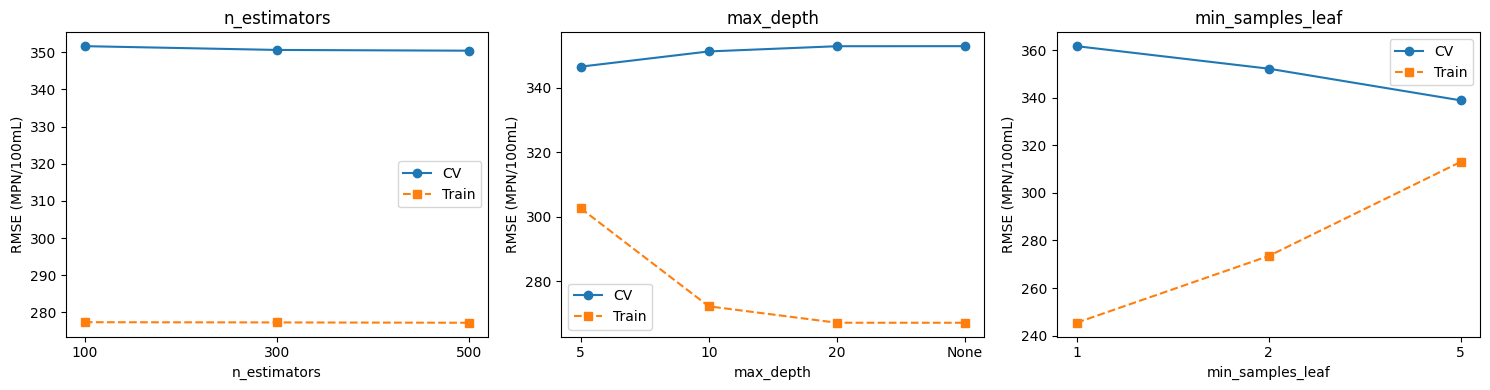

In [11]:
# Pull GridSearchCV results
results = pd.DataFrame(rf_grid.cv_results_)
results['cv_rmse'] = -results['mean_test_score']
results['train_rmse'] = -results['mean_train_score']

# Fill None with string so groupby keeps it
results['param_regressor__model__max_depth'] = (
    results['param_regressor__model__max_depth'].fillna('None')
)

# Plot one subplot per hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['n_estimators', 'max_depth', 'min_samples_leaf']):
    col = f'param_regressor__model__{param}'
    grouped = results.groupby(col)[['cv_rmse', 'train_rmse']].mean()
    
    ax.plot(grouped.index.astype(str), grouped['cv_rmse'], 'o-', label='CV')
    ax.plot(grouped.index.astype(str), grouped['train_rmse'], 's--', label='Train')
    ax.set_xlabel(param)
    ax.set_ylabel('RMSE (MPN/100mL)')
    ax.set_title(param)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/regression_rf_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The three subplots show how CV RMSE and Train RMSE respond to each hyperparameter, averaged across the other two.

- 'n_estimators': CV RMSE is essentially flat across 100, 300, 500. The number of trees reaches the highest quickly — more trees do not improve validation performance.

- 'max_depth': CV RMSE barely changes while Train RMSE drops as depth increases. The model gains capacity to fit the training set but not to generalise, which is a mild overfitting pattern.

- 'min_samples_leaf': The only hyperparameter with a clear CV trend. CV RMSE drops from 362 at 'min_samples_leaf=1' to around 339 at 'min_samples_leaf=5', while Train RMSE rises. 
This is regularisation working: larger leaves prevent trees from memorising individual training points.

The selected value 'min_samples_leaf=5' is the largest in the grid, so values like 7 or 10 might give slightly better CV RMSE. The improvement is likely small given the downward trend is already flattening.

## 4.4 MLP Regressor

A Multi-layer Perceptron will be conducted as mentioned in the EDA. It can capture non-linear relationships and feature interactions through hidden layers, but it tend to overfit on small datasets. 

Three key hyperparameters are tuned with 5-fold cross-validation:

- 'hidden_layer_sizes': structure of hidden layers (controls model capacity)
- 'alpha': L2 regularisation strength (controls overfitting)
- 'learning_rate_init': initial learning rate (controls training speed and stability)

In [12]:
# Build pipeline: preprocessing + MLP
mlp_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', MLPRegressor(
        max_iter=1000,
        early_stopping=False,
        random_state=42,
    ))
])
# Wrap with log transformation
mlp_reg = TransformedTargetRegressor(
    regressor=mlp_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)
# Hyperparameter grid
param_grid = {
    'regressor__model__hidden_layer_sizes': [(8,), (16,), (32,), (32, 16)],
    'regressor__model__alpha': [0.01, 0.1, 1, 10],
    'regressor__model__learning_rate_init': [0.001, 0.01],
}
# GridSearchCV
mlp_grid = GridSearchCV(
    mlp_reg,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, # Use all the capacity
    return_train_score=True,
)

mlp_grid.fit(X_train, y_reg_train)

# Best result
mlp_cv_rmse = -mlp_grid.best_score_
mlp_best_params = mlp_grid.best_params_

# Train RMSE
mlp_train_pred = mlp_grid.best_estimator_.predict(X_train)
mlp_train_rmse = root_mean_squared_error(y_reg_train, mlp_train_pred)

print(f"Best params: {mlp_best_params}")
print(f"MLP CV RMSE:    {mlp_cv_rmse:.1f} MPN/100mL")
print(f"MLP Train RMSE: {mlp_train_rmse:.1f} MPN/100mL")

Best params: {'regressor__model__alpha': 10, 'regressor__model__hidden_layer_sizes': (16,), 'regressor__model__learning_rate_init': 0.01}
MLP CV RMSE:    325.9 MPN/100mL
MLP Train RMSE: 323.3 MPN/100mL


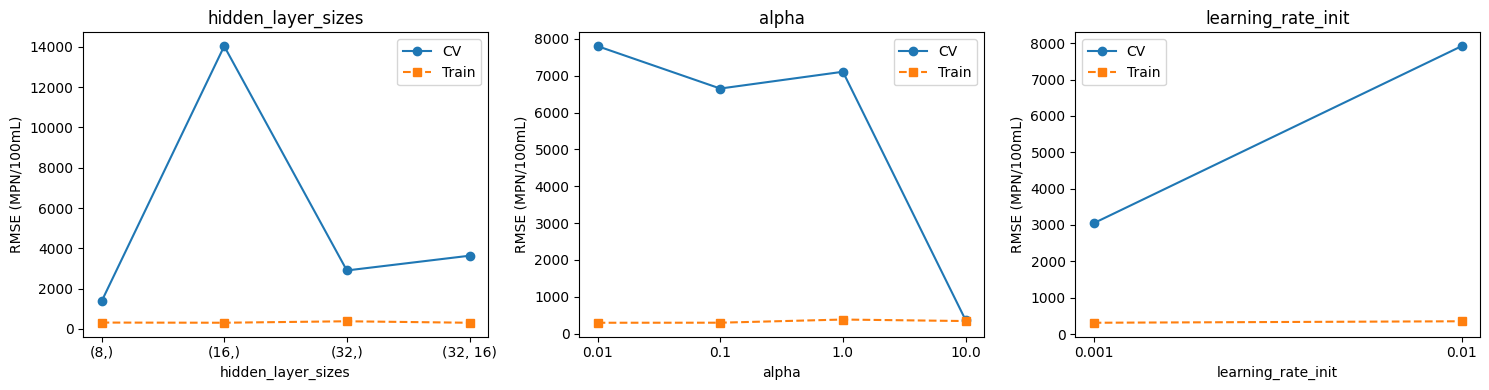

In [13]:
# Pull GridSearchCV results
results = pd.DataFrame(mlp_grid.cv_results_)
results['cv_rmse'] = -results['mean_test_score']
results['train_rmse'] = -results['mean_train_score']

# Plot one subplot per hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['hidden_layer_sizes', 'alpha', 'learning_rate_init']):
    col = f'param_regressor__model__{param}'
    grouped = results.groupby(col)[['cv_rmse', 'train_rmse']].mean()
    
    ax.plot(grouped.index.astype(str), grouped['cv_rmse'], 'o-', label='CV')
    ax.plot(grouped.index.astype(str), grouped['train_rmse'], 's--', label='Train')
    ax.set_xlabel(param)
    ax.set_ylabel('RMSE (MPN/100mL)')
    ax.set_title(param)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/regression_mlp_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The three subplots show the average CV RMSE and Train RMSE across all configurations at each hyperparameter value. Unlike Random Forest, the MLP curves show large spikes — caused by some configurations where the model fails to converge cleanly.

- 'hidden_layer_sizes': The spikes might come from unstable combinations, not from the network size itself. Train RMSE stays low (around 290) because training still converges; the problem only shows up on validation.

- 'alpha': CV RMSE drops sharply at 'alpha=10', where regularisation is strong enough to keep all combinations stable. The MLP clearly needs very strong regularisation on this dataset.

- 'learning_rate_init': A larger learning rate (0.01) will make it unstable while the regularisation is weak.

The selected configuration ((16,), alpha=10, lr=0.01) sits in the stable region, giving CV RMSE 326 and Train RMSE 323 — a tight gap that shows the model generalises as well as it fits. 

And also find that MLP performance depends heavily on hyperparameter choice on this small dataset, in a way Random 
Forest does not.

## 4.5 Compare and select final regression model



# 5. Classification Modelling

This section builds and tunes four classification models to predict 'ecoli_band' (A–E), alongside a 'DummyClassifier' baseline. Each model is built as a pipeline combining the preprocessor with the classifier. Class imbalance is handled by 'class_weight='balanced'', and 'StratifiedKFold' is used for cross-validation to preserve band proportions in every fold. Models are compared by macro-F1, as justified 
in Section 3. 

## 5.1 Dummy baseline

Establish a 'DummyClassifier' baseline with 'strategy='most_frequent'', which always predicts the majority band.

The dummy is evaluated using 5-fold cross-validation on the training set, with the same metric(macro F1) used to compare the other models.

In [ ]:
# Build the dummy 
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)

# 5-fold CV
cv_scores = cross_val_score(
    dummy_clf,
    X_train,
    y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro'
)

dummy_cv_f1 = cv_scores.mean()
dummy_cv_f1_std = cv_scores.std()

print(f"Dummy CV macro-F1: {dummy_cv_f1:.3f} ± {dummy_cv_f1_std:.3f}")

Dummy CV macro-F1: 0.094 ± 0.002


**Observation**

Dummy macro-F1 is just 0.094, which makes sense because the dummy only predicts the majority band D and gives zero F1 on the other four bands.

## 5.2 Logistic Regression

Logistic Regression is the simple baseline for the classification task. It assumes linear boudaries between bands, which might not fit very cleanly (observed in EDA). While this model still being trained to see how it goes.

'class_weight='balanced'' is used to give minority bands B (33) and C (20) the same weight as the majority bands during training. The regularisation strength 'C' is tuned with 5-fold stratified CV.

In [18]:
# Build pipeline: preprocessing + logistic regression
lor_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
    ))
])

# Hyperparameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0, 100.0],
}

# GridSearchCV with stratified CV
lor_grid = GridSearchCV(
    lor_pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    return_train_score=True,
)

lor_grid.fit(X_train, y_clf_train)

# Best result
lor_cv_f1 = lor_grid.best_score_
lor_best_params = lor_grid.best_params_

# Train F1
lor_train_pred = lor_grid.best_estimator_.predict(X_train)
lor_train_f1 = f1_score(y_clf_train, lor_train_pred, average='macro')

print(f"Best params: {lor_best_params}")
print(f"Logistic Regression CV macro-F1:    {lor_cv_f1:.3f}")
print(f"Logistic Regression Train macro-F1: {lor_train_f1:.3f}")

Best params: {'model__C': 100.0}
Logistic Regression CV macro-F1:    0.378
Logistic Regression Train macro-F1: 0.508
